In [ ]:
import os
import sys
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split


THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
TAGGING_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))
DATA_DIR = os.path.abspath(os.path.join(TAGGING_DIR, '..'))

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import model as model_mod  # noqa: E402
import importlib  # noqa: E402
importlib.reload(tool)  # noqa: E402
importlib.reload(model_mod)  # noqa: E402
from model import ParticleTransformerKD, SharedEncoderUnsmearClassifier  # noqa: E402

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

RUN_NAME = 'unsmear_transformer_sharedencoder'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')
SHARED_BASELINE_DIR = os.path.join(MODULE_DIR, 'runs', 'shared_offline_hlt_baselines')
SHARED_BASELINE_CKPT_DIR = os.path.join(SHARED_BASELINE_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)
tool.ensure_dir(SHARED_BASELINE_CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(DATA_DIR, 'test.h5'),
    'n_jets': 200000,
    'max_particles': 100,
    'feature_kind': '7d',
    'load_shared_baselines': True,
    'load_joint_model': False,
    'joint_model': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 4,
        'ff_dim': 512,
        'dropout': 0.1,
        'return_reco': True,
        'add_mask_channel': False,
        'mask_output': True,
        'use_positional_embedding': False,
        'max_seq_len': 128,
    },
    'hlt_effects': {
        'pt_threshold_offline': 0,
        'pt_threshold_hlt': 0,
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
    },
    'tagger': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
    },
    'kd': {
        'enable': True,
        'temperature': 3.0,
        'alpha_kd': 0.5,
        'alpha_attn': 0.0,
    },
    'training': {
        'batch_size': 256,
        'epochs': 50,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 8,
        'joint_unsmear_weight': 1.0,
        'joint_cls_weight': 1.0,
        'resmear_each_epoch_baselines': True,
        'resmear_each_epoch_joint': True,
        'resmear_seed_stride': 1,
    },
}

feat_names = tool.get_feat_names(CONFIG['feature_kind'])
CONFIG['joint_model']['input_dim'] = len(feat_names)
CONFIG['joint_model']['max_seq_len'] = int(CONFIG['max_particles'])
CONFIG['tagger']['input_dim'] = len(feat_names)

config_path = os.path.join(OUT_DIR, 'config.json')
tool.save_config(CONFIG, config_path)
print('Data path:', CONFIG['data_path'])
print('Run dir:', OUT_DIR)
print('Feature kind:', CONFIG['feature_kind'], 'feat_names:', feat_names)


Device: cuda
Data path: d:\PracticeTagging\tagging\test.h5
Run dir: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder
Feature kind: 7d feat_names: ['dEta', 'dPhi', 'log_pt', 'log_E', 'log_pt_rel', 'log_E_rel', 'dR']


In [2]:
# Load the raw constituents and build the offline / HLT views
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)
mask_raw = pt > 0
print('Raw:', constituents_raw.shape, 'mask:', mask_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))

hcfg = tool.HLTEffectsCfg(**CONFIG['hlt_effects'])
_, hlt_const, hlt_mask = tool.apply_hlt_effects_pair(
    constituents_raw,
    mask_raw,
    hcfg,
    seed=seed,
)

pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
off_mask = mask_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
off_const = constituents_raw.copy()
off_const[~off_mask] = 0.0
hlt_const = hlt_const.copy()
hlt_const[~hlt_mask] = 0.0

axis_off = tool.compute_jet_axis(off_const, off_mask)
axis_hlt = tool.compute_jet_axis(hlt_const, hlt_mask)
feat_off = tool.compute_features_with_axis(off_const, off_mask, axis_off, kind=CONFIG['feature_kind'])
feat_hlt = tool.compute_features_with_axis(hlt_const, hlt_mask, axis_hlt, kind=CONFIG['feature_kind'])

idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=seed, stratify=labels[temp_idx])
print(f'Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}')

feat_means, feat_stds = tool.get_stats(feat_off, off_mask, train_idx)
feat_off_std = tool.standardize(feat_off, off_mask, feat_means, feat_stds, clip=10.0)
feat_hlt_std = tool.standardize(feat_hlt, hlt_mask, feat_means, feat_stds, clip=10.0)
common_mask = off_mask & hlt_mask

x_joint = feat_hlt_std.copy()
y_joint = feat_off_std.copy()
x_joint[~common_mask] = 0.0
y_joint[~common_mask] = 0.0

train_const_raw = constituents_raw[train_idx]
train_mask_raw = mask_raw[train_idx]

print('Offline/HLT feature shape:', feat_off_std.shape, feat_hlt_std.shape)
print('Mask identical:', bool(np.array_equal(off_mask, hlt_mask)))
print('Common-mask fraction:', float(common_mask.mean()))
print('Feat means:', np.round(feat_means, 4))
print('Feat stds :', np.round(feat_stds, 4))
print('Baseline epoch resmear enabled:', bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)))
print('Joint epoch resmear enabled:', bool(CONFIG['training'].get('resmear_each_epoch_joint', False)))


Raw: (200000, 100, 4) mask: (200000, 100)
Signal: 99836 Bkg: 100164
Split: train=140,000 val=30,000 test=30,000
Offline/HLT feature shape: (200000, 100, 7) (200000, 100, 7)
Mask identical: True
Common-mask fraction: 0.5429243
Feat means: [-2.0000e-04 -1.0000e-04  8.7940e+00  9.0840e+00 -5.2585e+00 -5.2701e+00
  2.2250e-01]
Feat stds : [0.2121 0.2173 1.5182 1.5217 1.4919 1.4935 0.2067]
Epoch resmear enabled: True


In [3]:
# Build the datasets and loaders
BS = int(CONFIG['training']['batch_size'])
train_ds_hlt = tool.JetDataset(
    feat_off_std[train_idx],
    feat_hlt_std[train_idx],
    labels[train_idx],
    off_mask[train_idx],
    hlt_mask[train_idx],
    weights[train_idx],
)
val_ds_hlt = tool.JetDataset(
    feat_off_std[val_idx],
    feat_hlt_std[val_idx],
    labels[val_idx],
    off_mask[val_idx],
    hlt_mask[val_idx],
    weights[val_idx],
)
test_ds_hlt = tool.JetDataset(
    feat_off_std[test_idx],
    feat_hlt_std[test_idx],
    labels[test_idx],
    off_mask[test_idx],
    hlt_mask[test_idx],
    weights[test_idx],
)

train_ds_joint = tool.JointJetDataset(
    x_joint[train_idx],
    y_joint[train_idx],
    common_mask[train_idx],
    labels[train_idx],
    weights[train_idx],
)
val_ds_joint = tool.JointJetDataset(
    x_joint[val_idx],
    y_joint[val_idx],
    common_mask[val_idx],
    labels[val_idx],
    weights[val_idx],
)
test_ds_joint = tool.JointJetDataset(
    x_joint[test_idx],
    y_joint[test_idx],
    common_mask[test_idx],
    labels[test_idx],
    weights[test_idx],
)

train_loader_hlt = DataLoader(train_ds_hlt, batch_size=BS, shuffle=True, drop_last=True)
val_loader_hlt = DataLoader(val_ds_hlt, batch_size=BS, shuffle=False)
test_loader_hlt = DataLoader(test_ds_hlt, batch_size=BS, shuffle=False)

train_loader_joint = DataLoader(train_ds_joint, batch_size=BS, shuffle=True, drop_last=True)
val_loader_joint = DataLoader(val_ds_joint, batch_size=BS, shuffle=False)
test_loader_joint = DataLoader(test_ds_joint, batch_size=BS, shuffle=False)


def make_epoch_hlt_train_loader(epoch: int):
    return tool.make_epoch_hlt_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        feat_off_train=feat_off_std[train_idx],
        off_mask_train=off_mask[train_idx],
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=seed,
        fixed_feat_hlt_train=feat_hlt_std[train_idx],
        fixed_hlt_mask_train=hlt_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)),
        clip=10.0,
    )


def make_epoch_joint_train_loader(epoch: int):
    return tool.make_epoch_joint_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=seed,
        fixed_x_train=x_joint[train_idx],
        fixed_y_train=y_joint[train_idx],
        fixed_mask_train=common_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_joint', True)),
        clip=10.0,
    )


In [4]:
# Train the offline teacher, HLT / HLT+KD baselines, and the joint shared-encoder models (with / without KD)
train_cfg = CONFIG['training']
kd_cfg = CONFIG['kd']
hlt_train_loader_factory = make_epoch_hlt_train_loader if bool(train_cfg.get('resmear_each_epoch_baselines', False)) else None
joint_train_loader_factory = make_epoch_joint_train_loader if bool(train_cfg.get('resmear_each_epoch_joint', True)) else None

teacher = ParticleTransformerKD(**CONFIG['tagger']).to(device)
teacher_ckpt = os.path.join(SHARED_BASELINE_CKPT_DIR, 'teacher_offline.pt')
teacher = tool.train_or_load_standard_model(
    'Teacher(OFF_FULL)',
    teacher,
    teacher_ckpt,
    train_loader_hlt,
    val_loader_hlt,
    device=device,
    feat_key='off',
    mask_key='mask_off',
    allow_load=bool(CONFIG.get('load_shared_baselines', True)),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
)

student_hlt = ParticleTransformerKD(**CONFIG['tagger']).to(device)
student_hlt_ckpt = os.path.join(SHARED_BASELINE_CKPT_DIR, 'student_hlt.pt')
student_hlt = tool.train_or_load_standard_model(
    'Student(HLT)',
    student_hlt,
    student_hlt_ckpt,
    train_loader_hlt,
    val_loader_hlt,
    device=device,
    feat_key='hlt',
    mask_key='mask_hlt',
    allow_load=bool(CONFIG.get('load_shared_baselines', True)),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    train_loader_factory=hlt_train_loader_factory,
)

student_hlt_kd = ParticleTransformerKD(**CONFIG['tagger']).to(device)
student_hlt_kd_ckpt = os.path.join(SHARED_BASELINE_CKPT_DIR, 'student_hlt_kd.pt')
student_hlt_kd = tool.train_or_load_kd_standard_model(
    'Student(HLT)+KD',
    student_hlt_kd,
    teacher,
    student_hlt_kd_ckpt,
    train_loader_hlt,
    val_loader_hlt,
    device=device,
    allow_load=bool(CONFIG.get('load_shared_baselines', True)),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
    train_loader_factory=hlt_train_loader_factory,
)

joint_model_no_kd = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
joint_ckpt_no_kd = os.path.join(CKPT_DIR, 'joint_sharedencoder_no_kd.pt')
joint_model_no_kd = tool.train_or_load_joint_model(
    'JointSharedEncoder(HLT,no_kd)',
    joint_model_no_kd,
    joint_ckpt_no_kd,
    train_loader_joint,
    val_loader_joint,
    device=device,
    feat_names=feat_names,
    feat_stds=feat_stds,
    joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
    joint_cls_weight=float(train_cfg['joint_cls_weight']),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    teacher=teacher,
    use_kd=False,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
    allow_load=bool(CONFIG.get('load_joint_model', False)),
    train_loader_factory=joint_train_loader_factory,
)

joint_model_with_kd = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
joint_ckpt_with_kd = os.path.join(CKPT_DIR, 'joint_sharedencoder_with_kd.pt')
joint_model_with_kd = tool.train_or_load_joint_model(
    'JointSharedEncoder(HLT,with_kd)',
    joint_model_with_kd,
    joint_ckpt_with_kd,
    train_loader_joint,
    val_loader_joint,
    device=device,
    feat_names=feat_names,
    feat_stds=feat_stds,
    joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
    joint_cls_weight=float(train_cfg['joint_cls_weight']),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    teacher=teacher,
    use_kd=True,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
    allow_load=bool(CONFIG.get('load_joint_model', False)),
    train_loader_factory=joint_train_loader_factory,
)

auc_teacher, p_teacher, y_true = tool.evaluate(teacher, test_loader_hlt, device, 'off', 'mask_off')
auc_hlt, p_hlt, _ = tool.evaluate(student_hlt, test_loader_hlt, device, 'hlt', 'mask_hlt')
hlt_kd_test = tool.eval_kd_student(
    student_hlt_kd,
    teacher,
    test_loader_hlt,
    device,
    {'kd': {'temperature': float(kd_cfg['temperature']), 'alpha_kd': float(kd_cfg['alpha_kd']), 'alpha_attn': float(kd_cfg['alpha_attn'])}},
)
auc_hlt_kd = float(hlt_kd_test['auc'])
p_hlt_kd = np.asarray(hlt_kd_test['preds'])

joint_test_no_kd = tool.eval_joint_model(
    joint_model_no_kd,
    test_loader_joint,
    device=device,
    feat_names=feat_names,
    feat_stds=feat_stds,
    joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
    joint_cls_weight=float(train_cfg['joint_cls_weight']),
    teacher=teacher,
    use_kd=False,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
)

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Teacher(OFF_FULL)] ep=001 train_loss=0.54100 val_auc=0.84165 best=0.84165 no_imp=0
[Teacher(OFF_FULL)] ep=002 train_loss=0.48062 val_auc=0.87654 best=0.87654 no_imp=0
[Teacher(OFF_FULL)] ep=004 train_loss=0.38439 val_auc=0.92759 best=0.92759 no_imp=0
[Teacher(OFF_FULL)] ep=006 train_loss=0.35928 val_auc=0.93011 best=0.93011 no_imp=0
[Teacher(OFF_FULL)] ep=008 train_loss=0.34571 val_auc=0.92567 best=0.93506 no_imp=1
[Teacher(OFF_FULL)] ep=010 train_loss=0.33759 val_auc=0.93667 best=0.93995 no_imp=1
[Teacher(OFF_FULL)] ep=012 train_loss=0.33021 val_auc=0.93307 best=0.93995 no_imp=3
[Teacher(OFF_FULL)] ep=014 train_loss=0.32397 val_auc=0.93626 best=0.94164 no_imp=1
[Teacher(OFF_FULL)] ep=016 train_loss=0.31909 val_auc=0.93619 best=0.94164 no_imp=3
[Teacher(OFF_FULL)] ep=018 train_loss=0.31308 val_auc=0.94090 best=0.94164 no_imp=5
[Teacher(OFF_FULL)] ep=020 train_loss=0.30699 val_auc=0.94042 best=0.94164 no_imp=7
[Teacher(OFF_FULL)] Early stopping
Saved checkpoint: d:\PracticeTagging\tagg

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Student(HLT)] ep=001 train_loss=0.55252 val_auc=0.83852 best=0.83852 no_imp=0
[Student(HLT)] ep=002 train_loss=0.50377 val_auc=0.86928 best=0.86928 no_imp=0
[Student(HLT)] ep=004 train_loss=0.43978 val_auc=0.88591 best=0.89654 no_imp=1
[Student(HLT)] ep=006 train_loss=0.42396 val_auc=0.90040 best=0.90051 no_imp=1
[Student(HLT)] ep=008 train_loss=0.41263 val_auc=0.91539 best=0.91539 no_imp=0
[Student(HLT)] ep=010 train_loss=0.40852 val_auc=0.90682 best=0.91539 no_imp=2
[Student(HLT)] ep=012 train_loss=0.39963 val_auc=0.90374 best=0.91539 no_imp=4
[Student(HLT)] ep=014 train_loss=0.39749 val_auc=0.91475 best=0.91539 no_imp=6
[Student(HLT)] ep=016 train_loss=0.39293 val_auc=0.90721 best=0.91619 no_imp=1
[Student(HLT)] ep=018 train_loss=0.39020 val_auc=0.91274 best=0.91619 no_imp=3
[Student(HLT)] ep=020 train_loss=0.38418 val_auc=0.90834 best=0.91619 no_imp=5
[Student(HLT)] ep=022 train_loss=0.37907 val_auc=0.91215 best=0.91619 no_imp=7
[Student(HLT)] Early stopping
Saved checkpoint: d:\P

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Student(HLT)+KD] ep=001 train_loss=1.83387 val_auc=0.84753 best=0.84753 no_imp=0
[Student(HLT)+KD] ep=002 train_loss=1.70334 val_auc=0.90214 best=0.90214 no_imp=0
[Student(HLT)+KD] ep=004 train_loss=1.59736 val_auc=0.90318 best=0.90318 no_imp=0
[Student(HLT)+KD] ep=006 train_loss=1.57536 val_auc=0.91435 best=0.91435 no_imp=0
[Student(HLT)+KD] ep=008 train_loss=1.56624 val_auc=0.90420 best=0.91932 no_imp=1
[Student(HLT)+KD] ep=010 train_loss=1.55934 val_auc=0.91281 best=0.91932 no_imp=3
[Student(HLT)+KD] ep=012 train_loss=1.55326 val_auc=0.91612 best=0.91932 no_imp=5
[Student(HLT)+KD] ep=014 train_loss=1.54744 val_auc=0.90422 best=0.91932 no_imp=7
[Student(HLT)+KD] Early stopping
Saved checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\shared_offline_hlt_baselines\ckpts\student_hlt_kd.pt


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[JointSharedEncoder(HLT,no_kd)] ep=001 train_joint=0.64668 train_uns=0.08405 train_cls=0.56263 train_hard=0.56263 train_kd=0.00000 val_joint=0.57370 val_uns=0.04110 val_cls=0.53260 val_hard=0.53260 val_kd=0.00000 val_auc=0.81954 best=0.81954 no_imp=0
[JointSharedEncoder(HLT,no_kd)] ep=002 train_joint=0.55451 train_uns=0.04540 train_cls=0.50911 train_hard=0.50911 train_kd=0.00000 val_joint=0.51391 val_uns=0.03975 val_cls=0.47415 val_hard=0.47415 val_kd=0.00000 val_auc=0.86817 best=0.86817 no_imp=0
[JointSharedEncoder(HLT,no_kd)] ep=004 train_joint=0.47718 train_uns=0.03934 train_cls=0.43784 train_hard=0.43784 train_kd=0.00000 val_joint=0.49296 val_uns=0.03846 val_cls=0.45450 val_hard=0.45450 val_kd=0.00000 val_auc=0.88243 best=0.88243 no_imp=0
[JointSharedEncoder(HLT,no_kd)] ep=006 train_joint=0.45884 train_uns=0.03863 train_cls=0.42021 train_hard=0.42021 train_kd=0.00000 val_joint=0.44888 val_uns=0.03783 val_cls=0.41105 val_hard=0.41105 val_kd=0.00000 val_auc=0.90025 best=0.90206 no_im

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[JointSharedEncoder(HLT,with_kd)] ep=001 train_joint=1.94678 train_uns=0.08660 train_cls=1.86018 train_hard=0.57185 train_kd=2.41233 val_joint=1.83719 val_uns=0.04209 val_cls=1.79509 val_hard=0.55927 val_kd=2.32473 val_auc=0.84772 best=0.84772 no_imp=0
[JointSharedEncoder(HLT,with_kd)] ep=002 train_joint=1.77423 train_uns=0.04553 train_cls=1.72869 train_hard=0.50416 train_kd=2.25349 val_joint=1.76460 val_uns=0.04075 val_cls=1.72385 val_hard=0.51228 val_kd=2.24310 val_auc=0.88280 best=0.88280 no_imp=0
[JointSharedEncoder(HLT,with_kd)] ep=004 train_joint=1.64289 train_uns=0.03953 train_cls=1.60337 train_hard=0.43429 train_kd=2.10440 val_joint=1.64201 val_uns=0.03850 val_cls=1.60352 val_hard=0.45144 val_kd=2.09727 val_auc=0.90524 best=0.90524 no_imp=0
[JointSharedEncoder(HLT,with_kd)] ep=006 train_joint=1.61714 train_uns=0.03868 train_cls=1.57846 train_hard=0.41984 train_kd=2.07501 val_joint=1.61228 val_uns=0.03783 val_cls=1.57445 val_hard=0.42312 val_kd=2.06787 val_auc=0.90274 best=0.906

Teacher(OFF_FULL) AUC=0.94407
Student(HLT) AUC=0.92166
Student(HLT)+KD AUC=0.92269
JointSharedEncoder(HLT,no_kd) AUC=0.91933
JointSharedEncoder(HLT,with_kd) AUC=0.92770
Joint(no_kd) test unsmear loss=0.03719
Joint(with_kd) test unsmear loss=0.03524
Joint(no_kd) test cls hard loss=0.39486
Joint(with_kd) test cls hard loss=0.38950
Joint(with_kd) test cls kd loss=2.01279
Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\sharedencoder_joint_downstream_roc_logfpr_5lines.png


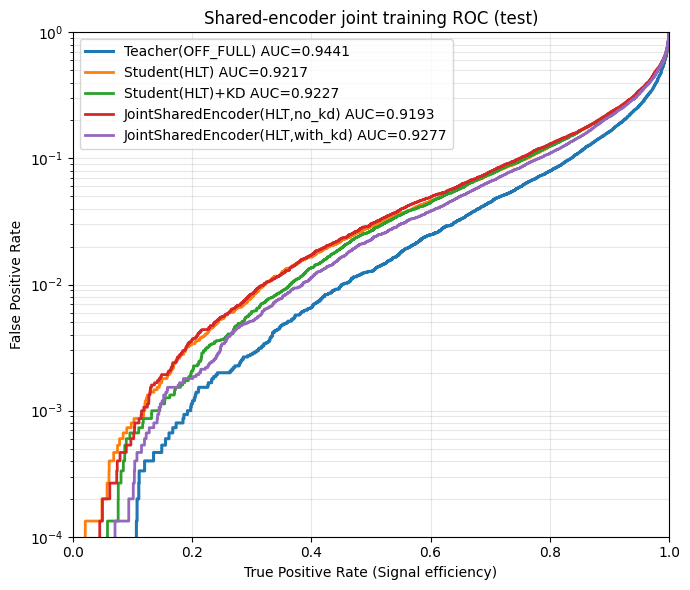

In [5]:
auc_joint_no_kd = float(joint_test_no_kd['auc'])
p_joint_no_kd = np.asarray(joint_test_no_kd['preds'])
y_joint_true = np.asarray(joint_test_no_kd['labels'])

joint_test_with_kd = tool.eval_joint_model(
    joint_model_with_kd,
    test_loader_joint,
    device=device,
    feat_names=feat_names,
    feat_stds=feat_stds,
    joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
    joint_cls_weight=float(train_cfg['joint_cls_weight']),
    teacher=teacher,
    use_kd=True,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
)
auc_joint_with_kd = float(joint_test_with_kd['auc'])
p_joint_with_kd = np.asarray(joint_test_with_kd['preds'])

print(f'Teacher(OFF_FULL) AUC={auc_teacher:.5f}')
print(f'Student(HLT) AUC={auc_hlt:.5f}')
print(f'Student(HLT)+KD AUC={auc_hlt_kd:.5f}')
print(f'Student(HLT)+KD test total loss={hlt_kd_test["total"]:.5f}')
print(f'Student(HLT)+KD test hard loss={hlt_kd_test["hard"]:.5f}')
print(f'Student(HLT)+KD test kd loss={hlt_kd_test["kd"]:.5f}')
print(f'Student(HLT)+KD test attn loss={hlt_kd_test["attn"]:.5f}')
print(f'JointSharedEncoder(HLT,no_kd) AUC={auc_joint_no_kd:.5f}')
print(f'JointSharedEncoder(HLT,with_kd) AUC={auc_joint_with_kd:.5f}')
print(f'Joint(no_kd) test unsmear loss={joint_test_no_kd["unsmear_total"]:.5f}')
print(f'Joint(with_kd) test unsmear loss={joint_test_with_kd["unsmear_total"]:.5f}')
print(f'Joint(no_kd) test cls hard loss={joint_test_no_kd["cls_hard_total"]:.5f}')
print(f'Joint(with_kd) test cls hard loss={joint_test_with_kd["cls_hard_total"]:.5f}')
print(f'Joint(with_kd) test cls kd loss={joint_test_with_kd["cls_kd_total"]:.5f}')
print(f'Joint(with_kd) test cls attn loss={joint_test_with_kd["cls_attn_total"]:.5f}')

fpr_teacher, tpr_teacher, _ = tool.compute_roc(y_true, p_teacher)
fpr_hlt, tpr_hlt, _ = tool.compute_roc(y_true, p_hlt)
fpr_hlt_kd, tpr_hlt_kd, _ = tool.compute_roc(y_true, p_hlt_kd)
fpr_joint_no_kd, tpr_joint_no_kd, _ = tool.compute_roc(y_joint_true, p_joint_no_kd)
fpr_joint_with_kd, tpr_joint_with_kd, _ = tool.compute_roc(y_joint_true, p_joint_with_kd)

plt.figure(figsize=(7, 6))
plt.semilogy(tpr_teacher, np.clip(fpr_teacher, 1e-6, 1.0), lw=2.2, label=f'Teacher(OFF_FULL) AUC={auc_teacher:.4f}')
plt.semilogy(tpr_hlt, np.clip(fpr_hlt, 1e-6, 1.0), lw=2.0, label=f'Student(HLT) AUC={auc_hlt:.4f}')
plt.semilogy(tpr_hlt_kd, np.clip(fpr_hlt_kd, 1e-6, 1.0), lw=2.0, label=f'Student(HLT)+KD AUC={auc_hlt_kd:.4f}')
plt.semilogy(tpr_joint_no_kd, np.clip(fpr_joint_no_kd, 1e-6, 1.0), lw=2.0, label=f'JointSharedEncoder(HLT,no_kd) AUC={auc_joint_no_kd:.4f}')
plt.semilogy(tpr_joint_with_kd, np.clip(fpr_joint_with_kd, 1e-6, 1.0), lw=2.0, label=f'JointSharedEncoder(HLT,with_kd) AUC={auc_joint_with_kd:.4f}')
plt.xlabel('True Positive Rate (Signal efficiency)')
plt.ylabel('False Positive Rate')
plt.title('Shared-encoder joint training ROC (test)')
plt.xlim(0.0, 1.0)
plt.ylim(1e-4, 1.0)
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()

roc_out = os.path.join(FIG_DIR, 'sharedencoder_joint_downstream_roc_logfpr_5lines.png')
plt.savefig(roc_out, dpi=180, bbox_inches='tight')
print('Saved figure:', roc_out)
plt.show()


Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dEta.png


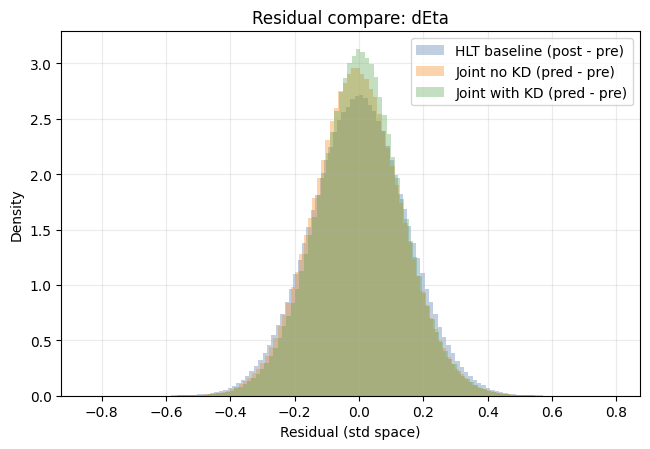

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dPhi.png


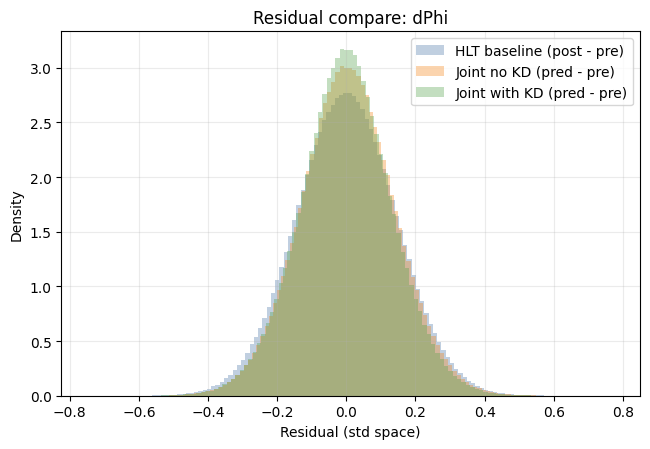

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_pt.png


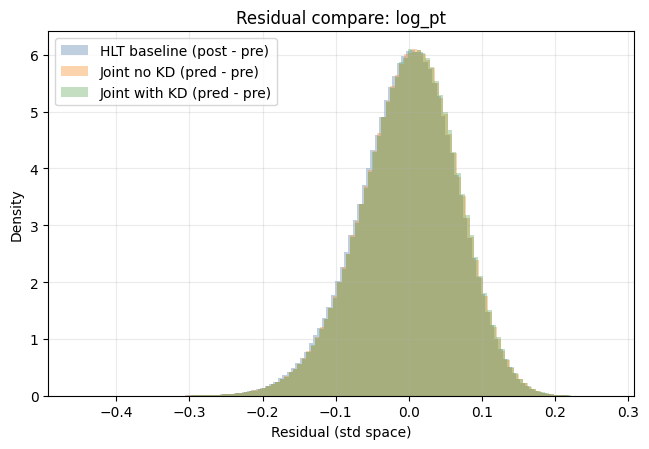

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_E.png


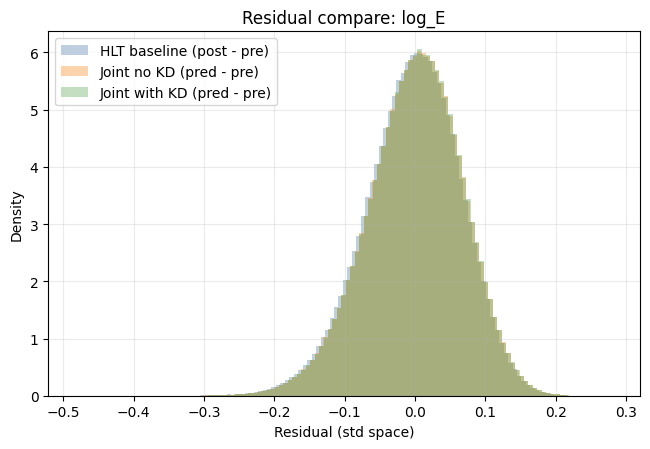

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_pt_rel.png


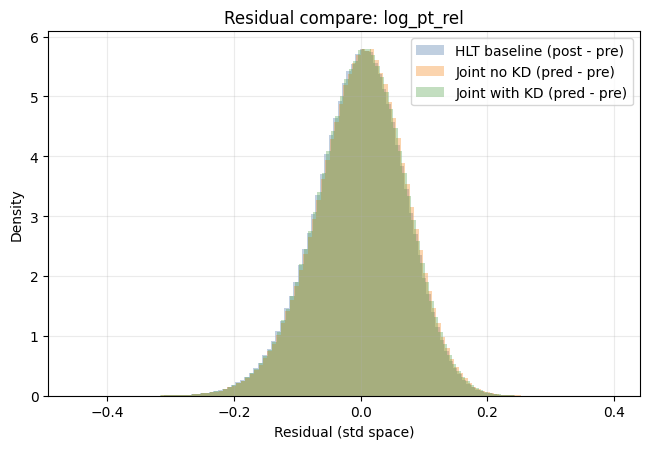

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_E_rel.png


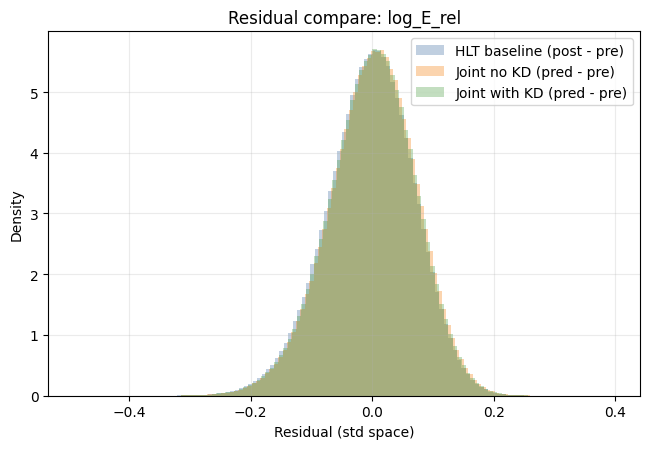

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dR.png


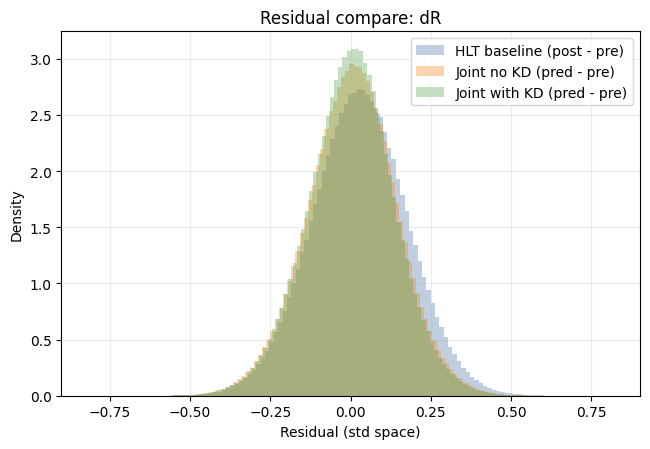


Metrics summary (std space) | split=test | n_tokens=1630900
   feature        method      bias      mae     rmse  abs_p50  abs_p90  abs_p99
      dEta           hlt -0.000556 0.118285 0.148658 0.099482 0.244542 0.385490
      dEta   joint_no_kd -0.005718 0.110289 0.139295 0.091970 0.229416 0.366883
      dEta joint_with_kd  0.002483 0.106326 0.135184 0.087550 0.223087 0.361525
      dPhi           hlt -0.000172 0.115474 0.145006 0.097246 0.238573 0.375467
      dPhi   joint_no_kd  0.004244 0.107649 0.135959 0.089735 0.224016 0.357593
      dPhi joint_with_kd -0.000840 0.104027 0.132105 0.085850 0.217998 0.351853
    log_pt           hlt -0.003360 0.052877 0.066770 0.044331 0.108811 0.177613
    log_pt   joint_no_kd -0.000090 0.052825 0.066539 0.044479 0.108500 0.175295
    log_pt joint_with_kd  0.000221 0.052801 0.066492 0.044469 0.108455 0.175047
     log_E           hlt -0.003796 0.053589 0.067663 0.044937 0.110348 0.179946
     log_E   joint_no_kd -0.000122 0.053506 0.067380 0.0450

,feature,method,bias,mae,rmse,abs_p50,abs_p90,abs_p99
0,dEta,hlt,-0.000556,0.118285,0.148658,0.099482,0.244542,0.385490
1,dEta,joint_no_kd,-0.005718,0.110289,0.139295,0.091970,0.229416,0.366883
2,dEta,joint_with_kd,0.002483,0.106326,0.135184,0.087550,0.223087,0.361525
3,dPhi,hlt,-0.000172,0.115474,0.145006,0.097246,0.238573,0.375467
4,dPhi,joint_no_kd,0.004244,0.107649,0.135959,0.089735,0.224016,0.357593
5,dPhi,joint_with_kd,-0.000840,0.104027,0.132105,0.085850,0.217998,0.351853
6,log_pt,hlt,-0.003360,0.052877,0.066770,0.044331,0.108811,0.177613
7,log_pt,joint_no_kd,-0.000090,0.052825,0.066539,0.044479,0.108500,0.175295
8,log_pt,joint_with_kd,0.000221,0.052801,0.066492,0.044469,0.108455,0.175047
9,log_E,hlt,-0.003796,0.053589,0.067663,0.044937,0.110348,0.179946


In [7]:
# Visualize unsmear reconstruction performance on the test set
import pandas as pd


@torch.no_grad()
def predict_joint_reco(model, loader):
    model.eval()
    outs = []
    for batch in loader:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        reco, _logits = model(x, m)
        outs.append(reco.detach().cpu().numpy())
    return np.concatenate(outs, axis=0)


def metric_dict(res_1d: np.ndarray):
    if res_1d.size == 0:
        return {
            'bias': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'abs_p50': np.nan,
            'abs_p90': np.nan,
            'abs_p99': np.nan,
        }
    abs_r = np.abs(res_1d)
    return {
        'bias': float(np.mean(res_1d)),
        'mae': float(np.mean(abs_r)),
        'rmse': float(np.sqrt(np.mean(res_1d ** 2))),
        'abs_p50': float(np.quantile(abs_r, 0.50)),
        'abs_p90': float(np.quantile(abs_r, 0.90)),
        'abs_p99': float(np.quantile(abs_r, 0.99)),
    }


def maybe_wrap_residual(name: str, feat_idx: int, residual: np.ndarray) -> np.ndarray:
    if name == 'dPhi':
        sc = float(feat_stds[feat_idx])
        return tool.wrap_dphi_np(residual * sc) / sc
    return residual


pred_joint_no_kd_reco = predict_joint_reco(joint_model_no_kd, test_loader_joint)
pred_joint_with_kd_reco = predict_joint_reco(joint_model_with_kd, test_loader_joint)

x_test_std = x_joint[test_idx]
y_test_std = y_joint[test_idx]
mask_test = common_mask[test_idx]

residual_sources = {
    'hlt': x_test_std - y_test_std,
    'joint_no_kd': pred_joint_no_kd_reco - y_test_std,
    'joint_with_kd': pred_joint_with_kd_reco - y_test_std,
}
plot_labels = {
    'hlt': 'HLT baseline (post - pre)',
    'joint_no_kd': 'Joint no KD (pred - pre)',
    'joint_with_kd': 'Joint with KD (pred - pre)',
}
plot_colors = {
    'hlt': '#4C78A8',
    'joint_no_kd': '#F58518',
    'joint_with_kd': '#54A24B',
}

metrics_rows = []
for feat_idx, feat_name in enumerate(feat_names):
    plt.figure(figsize=(6.6, 4.6))
    for method_name in ['hlt', 'joint_no_kd', 'joint_with_kd']:
        residual = residual_sources[method_name][..., feat_idx][mask_test]
        residual = maybe_wrap_residual(feat_name, feat_idx, residual)
        plt.hist(
            residual,
            bins=120,
            density=True,
            alpha=0.35,
            label=plot_labels[method_name],
            color=plot_colors[method_name],
        )
        mm = metric_dict(residual)
        metrics_rows.append({
            'feature': feat_name,
            'method': method_name,
            **mm,
        })

    plt.title(f'Residual compare: {feat_name}')
    plt.xlabel('Residual (std space)')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'joint_reco_residual_compare_{feat_name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[['feature', 'method', 'bias', 'mae', 'rmse', 'abs_p50', 'abs_p90', 'abs_p99']]

print()
print('=' * 100)
print(f'Metrics summary (std space) | split=test | n_tokens={int(mask_test.sum())}')
print('=' * 100)
print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

metrics_out = os.path.join(OUT_DIR, 'joint_reco_metrics_summary_test.csv')
metrics_df.to_csv(metrics_out, index=False)
print('Saved table:', metrics_out)

try:
    from IPython.display import display
    display(metrics_df)
except Exception:
    pass


In [ ]:
# Shared-trunk gradient diagnostics on a fixed probe batch
grad_probe_batch_hlt = tool.clone_batch_to_cpu(next(iter(test_loader_hlt)))
grad_probe_batch_joint = tool.clone_batch_to_cpu(next(iter(test_loader_joint)))

grad_diag_hlt_kd = tool.probe_hlt_kd_gradients(
    student_hlt_kd,
    teacher,
    grad_probe_batch_hlt,
    device=device,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
)
grad_diag_joint_no_kd = tool.probe_joint_gradients(
    joint_model_no_kd,
    grad_probe_batch_joint,
    device=device,
    feat_names=feat_names,
    feat_stds=feat_stds,
    teacher=teacher,
    use_kd=False,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
)
grad_diag_joint_with_kd = tool.probe_joint_gradients(
    joint_model_with_kd,
    grad_probe_batch_joint,
    device=device,
    feat_names=feat_names,
    feat_stds=feat_stds,
    teacher=teacher,
    use_kd=True,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
)


def build_grad_frames(model_name: str, diag: dict):
    scalar_row = {'model': model_name, **diag['scalar_losses']}
    norms_df = pd.DataFrame(diag['norm_rows'])
    cos_df = pd.DataFrame(diag['cosine_rows'])
    norms_df['model'] = model_name
    cos_df['model'] = model_name
    norms_df = norms_df[norms_df['loss_component'].isin(['unsmear', 'hard', 'kd', 'attn'])].copy()
    cos_df = cos_df[cos_df['pair'].isin([
        'unsmear_vs_hard',
        'unsmear_vs_kd',
        'unsmear_vs_attn',
        'hard_vs_kd',
        'hard_vs_attn',
        'kd_vs_attn',
    ])].copy()
    return pd.DataFrame([scalar_row]), norms_df, cos_df


scalar_hlt_kd, norms_hlt_kd, cos_hlt_kd = build_grad_frames('hlt_kd', grad_diag_hlt_kd)
scalar_joint_no_kd, norms_joint_no_kd, cos_joint_no_kd = build_grad_frames('joint_no_kd', grad_diag_joint_no_kd)
scalar_joint_with_kd, norms_joint_with_kd, cos_joint_with_kd = build_grad_frames('joint_with_kd', grad_diag_joint_with_kd)

grad_scalar_df = pd.concat([scalar_hlt_kd, scalar_joint_no_kd, scalar_joint_with_kd], ignore_index=True)
grad_norms_df = pd.concat([norms_hlt_kd, norms_joint_no_kd, norms_joint_with_kd], ignore_index=True)
grad_cos_df = pd.concat([cos_hlt_kd, cos_joint_no_kd, cos_joint_with_kd], ignore_index=True)

grad_scalar_out = os.path.join(OUT_DIR, 'shared_grad_probe_scalar_losses.csv')
grad_norms_out = os.path.join(OUT_DIR, 'shared_grad_probe_norms.csv')
grad_cos_out = os.path.join(OUT_DIR, 'shared_grad_probe_cosines.csv')
grad_scalar_df.to_csv(grad_scalar_out, index=False)
grad_norms_df.to_csv(grad_norms_out, index=False)
grad_cos_df.to_csv(grad_cos_out, index=False)

print()
print('=' * 110)
print('Gradient probe scalar losses (fixed test batch)')
print('=' * 110)
print(grad_scalar_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print()
print('=' * 110)
print('Gradient norms on shared trunk (fixed test batch)')
print('=' * 110)
print(grad_norms_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print()
print('=' * 110)
print('Gradient cosine on shared trunk (fixed test batch)')
print('=' * 110)
print(grad_cos_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print('Saved table:', grad_scalar_out)
print('Saved table:', grad_norms_out)
print('Saved table:', grad_cos_out)


group_order = ['shared_all', 'input_proj', 'layer_1', 'layer_last']
group_title = {
    'shared_all': 'shared_all',
    'input_proj': 'input_proj',
    'layer_1': 'layer_1',
    'layer_last': 'layer_last',
}
loss_order = ['unsmear', 'hard', 'kd', 'attn']
loss_color = {'unsmear': '#4C78A8', 'hard': '#F58518', 'kd': '#54A24B', 'attn': '#E45756'}
pair_order = ['unsmear_vs_hard', 'unsmear_vs_kd', 'unsmear_vs_attn', 'hard_vs_kd', 'hard_vs_attn', 'kd_vs_attn']
pair_color = {
    'unsmear_vs_hard': '#E45756',
    'unsmear_vs_kd': '#72B7B2',
    'unsmear_vs_attn': '#EECA3B',
    'hard_vs_kd': '#B279A2',
    'hard_vs_attn': '#FF9DA6',
    'kd_vs_attn': '#9D755D',
}


def plot_grad_norms_for_model(model_name: str, norms_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        sub = norms_df[norms_df['group'] == group_name].copy()
        sub = sub.set_index('loss_component').reindex(loss_order).dropna(how='all').reset_index()
        if sub.empty:
            ax.axis('off')
            continue
        xs = np.arange(len(sub))
        ys = sub['grad_norm'].to_numpy(dtype=float)
        colors = [loss_color.get(k, '#888888') for k in sub['loss_component']]
        ax.bar(xs, ys, color=colors, alpha=0.85)
        ax.set_xticks(xs)
        ax.set_xticklabels(sub['loss_component'], rotation=20)
        ax.set_title(f"{group_title[group_name]}\n{sub['group_module'].iloc[0]}")
        ax.set_ylabel('Grad norm')
        ax.grid(True, axis='y', alpha=0.25)
    fig.suptitle(f'Gradient norms: {model_name}')
    fig.tight_layout()
    out = os.path.join(FIG_DIR, f'{model_name}_shared_grad_norms.png')
    fig.savefig(out, dpi=170, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()


def plot_grad_cosines_for_model(model_name: str, cos_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        sub = cos_df[cos_df['group'] == group_name].copy()
        sub = sub.set_index('pair').reindex(pair_order).dropna(how='all').reset_index()
        if sub.empty:
            ax.axis('off')
            continue
        xs = np.arange(len(sub))
        ys = sub['cosine'].to_numpy(dtype=float)
        colors = [pair_color.get(k, '#888888') for k in sub['pair']]
        ax.bar(xs, ys, color=colors, alpha=0.85)
        ax.axhline(0.0, color='black', lw=1.0, alpha=0.6)
        ax.set_ylim(-1.05, 1.05)
        ax.set_xticks(xs)
        ax.set_xticklabels(sub['pair'], rotation=20)
        ax.set_title(f"{group_title[group_name]}\n{sub['group_module'].iloc[0]}")
        ax.set_ylabel('Cosine')
        ax.grid(True, axis='y', alpha=0.25)
    fig.suptitle(f'Gradient cosine: {model_name}')
    fig.tight_layout()
    out = os.path.join(FIG_DIR, f'{model_name}_shared_grad_cosines.png')
    fig.savefig(out, dpi=170, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()


plot_grad_norms_for_model('hlt_kd', norms_hlt_kd)
plot_grad_cosines_for_model('hlt_kd', cos_hlt_kd)
plot_grad_norms_for_model('joint_no_kd', norms_joint_no_kd)
plot_grad_cosines_for_model('joint_no_kd', cos_joint_no_kd)
plot_grad_norms_for_model('joint_with_kd', norms_joint_with_kd)
plot_grad_cosines_for_model('joint_with_kd', cos_joint_with_kd)

try:
    from IPython.display import display
    display(grad_scalar_df)
    display(grad_norms_df)
    display(grad_cos_df)
except Exception:
    pass


In [ ]:
# Inspect pooling attention for several test jets (offline / joint_no_kd / joint_with_kd comparison)
N_SHOW_PER_CLASS = 3
TOPK_CONST = 12
SCATTER_TOPK = 20
ATTN_SORT_BY = 'joint_with_kd'
ATTN_SYSTEMS = ['offline', 'joint_no_kd', 'joint_with_kd']
ATTN_COLORS = {
    'offline': '#4C78A8',
    'joint_no_kd': '#F58518',
    'joint_with_kd': '#54A24B',
}


def pick_attention_jets(labels_np: np.ndarray, n_per_class: int = 3):
    picked = []
    for cls in [1, 0]:
        idx_cls = np.where(labels_np == cls)[0]
        picked.extend(idx_cls[:n_per_class].tolist())
    return picked


@torch.no_grad()
def get_attention_standard_for_indices(model, x_np, mask_np, indices):
    model.eval()
    x = torch.tensor(x_np[indices], dtype=torch.float32, device=device)
    m = torch.tensor(mask_np[indices], dtype=torch.bool, device=device)
    logits, attn = model(x, m, return_attention=True)
    return {
        'logits': logits.squeeze(-1).detach().cpu().numpy(),
        'attn': attn.detach().cpu().numpy(),
    }


@torch.no_grad()
def get_attention_joint_for_indices(model, x_np, mask_np, indices):
    model.eval()
    x = torch.tensor(x_np[indices], dtype=torch.float32, device=device)
    m = torch.tensor(mask_np[indices], dtype=torch.bool, device=device)
    reco, logits, attn = model(x, m, return_attention=True)
    return {
        'reco': reco.detach().cpu().numpy(),
        'logits': logits.squeeze(-1).detach().cpu().numpy(),
        'attn': attn.detach().cpu().numpy(),
    }


selected_local_idx = pick_attention_jets(labels[test_idx], n_per_class=N_SHOW_PER_CLASS)
attn_offline = get_attention_standard_for_indices(teacher, feat_off_std[test_idx], off_mask[test_idx], selected_local_idx)
attn_joint_no_kd = get_attention_joint_for_indices(joint_model_no_kd, x_joint[test_idx], common_mask[test_idx], selected_local_idx)
attn_joint_with_kd = get_attention_joint_for_indices(joint_model_with_kd, x_joint[test_idx], common_mask[test_idx], selected_local_idx)

for plot_i, local_idx in enumerate(selected_local_idx):
    global_idx = int(test_idx[local_idx])
    label_i = int(labels[global_idx])
    weight_i = float(weights[global_idx])
    mask_i = common_mask[global_idx]
    valid_idx = np.where(mask_i)[0]

    attn_map = {
        'offline': attn_offline['attn'][plot_i][valid_idx],
        'joint_no_kd': attn_joint_no_kd['attn'][plot_i][valid_idx],
        'joint_with_kd': attn_joint_with_kd['attn'][plot_i][valid_idx],
    }
    prob_map = {
        'offline': 1.0 / (1.0 + np.exp(-float(attn_offline['logits'][plot_i]))),
        'joint_no_kd': 1.0 / (1.0 + np.exp(-float(attn_joint_no_kd['logits'][plot_i]))),
        'joint_with_kd': 1.0 / (1.0 + np.exp(-float(attn_joint_with_kd['logits'][plot_i]))),
    }

    feat_hlt_i = x_joint[global_idx][valid_idx]
    feat_off_i = y_joint[global_idx][valid_idx]
    reco_no_kd_i = attn_joint_no_kd['reco'][plot_i][valid_idx]
    reco_with_kd_i = attn_joint_with_kd['reco'][plot_i][valid_idx]

    sort_attn = attn_map[ATTN_SORT_BY]
    order = np.argsort(-sort_attn)
    top_order = order[:TOPK_CONST]
    top_valid_idx = valid_idx[top_order]

    jet_df = pd.DataFrame({
        'token_rank': np.arange(1, len(top_order) + 1),
        'const_idx': top_valid_idx,
        'attn_offline': attn_map['offline'][top_order],
        'attn_offline_pct': 100.0 * attn_map['offline'][top_order],
        'attn_joint_no_kd': attn_map['joint_no_kd'][top_order],
        'attn_joint_no_kd_pct': 100.0 * attn_map['joint_no_kd'][top_order],
        'attn_joint_with_kd': attn_map['joint_with_kd'][top_order],
        'attn_joint_with_kd_pct': 100.0 * attn_map['joint_with_kd'][top_order],
    })

    for feat_j, feat_name in enumerate(feat_names):
        jet_df[f'hlt_{feat_name}_std'] = feat_hlt_i[top_order, feat_j]
        jet_df[f'offline_{feat_name}_std'] = feat_off_i[top_order, feat_j]
        jet_df[f'reco_no_kd_{feat_name}_std'] = reco_no_kd_i[top_order, feat_j]
        jet_df[f'reco_with_kd_{feat_name}_std'] = reco_with_kd_i[top_order, feat_j]

    print()
    print('=' * 140)
    print(
        f'Attention inspection | test_local={local_idx} | global={global_idx} | label={label_i} '
        f'| weight={weight_i:.4f} | n_valid={len(valid_idx)} '
        f'| prob_offline={prob_map["offline"]:.6f} '
        f'| prob_joint_no_kd={prob_map["joint_no_kd"]:.6f} '
        f'| prob_joint_with_kd={prob_map["joint_with_kd"]:.6f}'
    )
    print('=' * 140)
    print(jet_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

    x_bar = np.arange(len(top_order))
    width = 0.26
    topk_scatter = order[: min(SCATTER_TOPK, len(order))]
    x_scatter = feat_hlt_i[topk_scatter, 0]
    y_scatter = feat_hlt_i[topk_scatter, 1]

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.8), gridspec_kw={'width_ratios': [1.3, 1.0, 1.0, 1.0]})

    ax_bar = axes[0]
    ax_bar.bar(x_bar - width, attn_map['offline'][top_order], width=width, color=ATTN_COLORS['offline'], alpha=0.85, label='offline')
    ax_bar.bar(x_bar, attn_map['joint_no_kd'][top_order], width=width, color=ATTN_COLORS['joint_no_kd'], alpha=0.85, label='joint_no_kd')
    ax_bar.bar(x_bar + width, attn_map['joint_with_kd'][top_order], width=width, color=ATTN_COLORS['joint_with_kd'], alpha=0.85, label='joint_with_kd')
    ax_bar.set_xticks(x_bar)
    ax_bar.set_xticklabels(top_valid_idx, rotation=35)
    ax_bar.set_xlabel('Constituent index')
    ax_bar.set_ylabel('Attention weight')
    ax_bar.set_title(f'Attention compare top-{len(top_order)} | sorted by {ATTN_SORT_BY}')
    ax_bar.grid(True, axis='y', alpha=0.25)
    ax_bar.legend()

    vmin = min(float(attn_map[k][topk_scatter].min()) for k in ATTN_SYSTEMS)
    vmax = max(float(attn_map[k][topk_scatter].max()) for k in ATTN_SYSTEMS)
    for ax, sys_name in zip(axes[1:], ATTN_SYSTEMS):
        attn_scatter = attn_map[sys_name][topk_scatter]
        sc = ax.scatter(
            x_scatter,
            y_scatter,
            s=60 + 900 * (attn_scatter / np.maximum(attn_scatter.max(), 1e-12)),
            c=attn_scatter,
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            alpha=0.85,
            edgecolors='black',
            linewidths=0.4,
        )
        for ord_j in topk_scatter[: min(10, len(topk_scatter))]:
            ax.text(
                feat_hlt_i[ord_j, 0],
                feat_hlt_i[ord_j, 1],
                str(valid_idx[ord_j]),
                fontsize=8,
                ha='center',
                va='center',
                color='white',
            )
        ax.set_xlabel('HLT dEta (std)')
        ax.set_ylabel('HLT dPhi (std)')
        ax.set_title(f'{sys_name} attention map')
        ax.grid(True, alpha=0.25)

    cbar = fig.colorbar(sc, ax=axes[1:].tolist(), shrink=0.95)
    cbar.set_label('Attention weight')

    fig.tight_layout()
    out = os.path.join(FIG_DIR, f'attention_compare_jet_{global_idx}.png')
    fig.savefig(out, dpi=170, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()
